# Задание 14. Свёрточная нейронная сеть для задачи регрессии (координаты солнца)

Что нужно сделать:
- Датасет: 2000 RGB-картинок 256x256, на каждой нарисовано солнце. Целевые переменные **Y** —
  координаты солнца `(x, y)` на картинке, обе меняются от 0 до 255.
- Подготовить данные способом «для регрессии»: свой класс на `torch.utils.data.Dataset`, который
  читает картинку с диска по имени файла из `labels.csv` и возвращает пару
  (тензор картинки, тензор из двух координат), и обернуть его в `DataLoader`.
- Адаптировать свёрточную архитектуру из задания 13 под регрессию: несколько блоков
  `conv – ReLU – pool`, затем полносвязная часть, но на выходе **2 нейрона** и никакого softmax.
- Функция потерь — регрессионная (`nn.MSELoss`), метрики — MAE, MSE, RMSE, R^2 плюс средняя ошибка
  в пикселях по каждой координате.
- Построить кривые обучения, графики «прогноз против истины» для x и для y и нарисовать
  предсказанную и истинную точку прямо поверх нескольких тестовых картинок.

In [1]:
import os

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms

from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

torch.manual_seed(42)
np.random.seed(42)

## Часть 1. Данные

### Шаг 1. Загружаем разметку

Картинки лежат в папке `images`, а разметка — в `labels.csv`: имя файла и две координаты солнца.

In [2]:
labels = pd.read_csv("labels.csv")

print("картинок:", len(labels))
labels.head()

картинок: 2000


,image,x,y
0,sun_reg_1.png,133,164
1,sun_reg_2.png,76,132
2,sun_reg_3.png,78,112
3,sun_reg_4.png,156,220
4,sun_reg_5.png,196,129


In [3]:
labels[["x", "y"]].describe()

,x,y
count,2000.000000,2000.000000
mean,126.115000,127.897500
std,56.724471,56.032989
min,32.000000,32.000000
25%,76.000000,77.000000
50%,125.000000,128.000000
75%,177.000000,177.000000
max,224.000000,224.000000


Разметка на 2000 картинок, обе координаты лежат в диапазоне 32-224 (солнце нарисовано целиком,
поэтому к самому краю его центр не подходит) и распределены примерно равномерно вокруг середины
картинки — средние 126 и 128.

### Шаг 2. Смотрим на картинки и проверяем соглашение о координатах

Прежде чем что-то обучать, надо понять, что означают `x` и `y`: номер столбца и номер строки — или
наоборот. Картинки квадратные, поэтому перепутанные оси не вызовут никакой ошибки, а просто молча
испортят результат. Нарисуем несколько картинок и поставим маркер в точку `(x, y)`: у `plt.scatter`
первый аргумент — горизонтальная ось, то есть столбец.

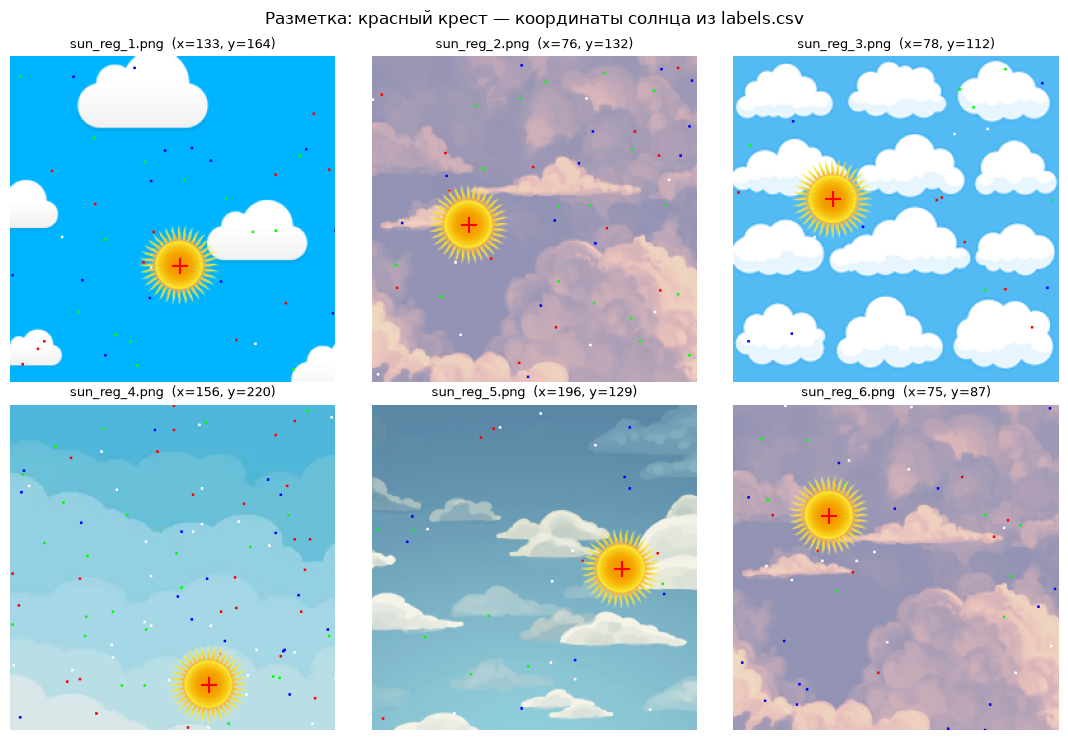

In [4]:
fig, axes = plt.subplots(2, 3, figsize=(11, 7.5))

for ax, i in zip(axes.flatten(), range(6)):
    img = Image.open(os.path.join("images", labels.loc[i, "image"])).convert("RGB")
    ax.imshow(img)
    ax.scatter(labels.loc[i, "x"], labels.loc[i, "y"], s=120, marker="+", c="red")
    ax.set_title(f'{labels.loc[i, "image"]}  (x={labels.loc[i, "x"]}, y={labels.loc[i, "y"]})',
                 fontsize=9)
    ax.axis("off")

fig.suptitle("Разметка: красный крест — координаты солнца из labels.csv")
plt.tight_layout()
plt.show()

Крест каждый раз попадает ровно в центр солнца, значит `x` — это номер столбца, а `y` — номер строки
(при индексации массива было бы `a[y, x]`). Дальше держим этот порядок везде и не меняем его местами.

Ещё одна деталь, которую видно только при загрузке: PNG-файлы лежат в режиме RGBA, то есть у них
4 канала. Сети нужны 3, поэтому при чтении обязателен `.convert("RGB")`, иначе на вход приедет
лишний канал прозрачности.

### Шаг 3. Свой `Dataset` и `DataLoader`

Это и есть «загрузка данных для регрессии»: в отличие от классификации метка не берётся из имени
папки, а читается из csv, и возвращается не число-класс, а тензор из двух чисел. Класс наследуем от
`torch.utils.data.Dataset` и реализуем `__len__` и `__getitem__`. Картинку читаем с диска
по индексу — все 2000 файлов (86 МБ) держать в памяти незачем.

Два решения по подготовке:

- **Уменьшаем картинку до 64x64** трансформом `transforms.Resize`. На процессоре свёртки по
  256x256 считаются медленно (эпоха занимала бы минуты), а солнце — крупное яркое пятно, его
  положение прекрасно видно и на уменьшенной картинке. Координаты при этом остаются в исходном
  масштабе 0-255: сеть учится на уменьшенной картинке, но предсказывает координаты полноразмерной.
- **Целевые переменные делим на 255**, то есть учим сеть на числах из [0, 1] — так же, как мы делили
  на 255 пиксели в заданиях 10 и 13. С «сырыми» числами до 255 квадратичная ошибка на старте
  получается огромной и обучение идёт заметно хуже. Все метрики потом считаем в пикселях, умножив
  прогноз обратно на 255.

In [5]:
img_size = 64

transform = transforms.Compose([
    transforms.Resize((img_size, img_size)),
    transforms.ToTensor(),          # (3, 64, 64), значения пикселей уже в [0, 1]
])


class SunDataset(Dataset):
    def __init__(self, df, folder, transform):
        self.df = df.reset_index(drop=True)
        self.folder = folder
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, i):
        row = self.df.loc[i]
        img = Image.open(os.path.join(self.folder, row["image"])).convert("RGB")
        # две целевые величины в одном тензоре, отмасштабированные в [0, 1]
        target = torch.tensor([row["x"] / 255.0, row["y"] / 255.0], dtype=torch.float32)
        return self.transform(img), target

In [6]:
train_df, test_df = train_test_split(labels, test_size=0.2, random_state=42)

train_ds = SunDataset(train_df, "images", transform)
test_ds = SunDataset(test_df, "images", transform)

train_loader = DataLoader(train_ds, batch_size=32, shuffle=True)
test_loader = DataLoader(test_ds, batch_size=32)

print("обучающая:", len(train_ds), " тестовая:", len(test_ds))

обучающая: 1600  тестовая: 400


In [7]:
# проверяем, что из загрузчика приходит именно то, что нужно
X_batch, y_batch = next(iter(train_loader))

print("картинки:", X_batch.shape, " целевые:", y_batch.shape)
print("пиксели от", X_batch.min().item(), "до", X_batch.max().item())
print("первые три цели (x, y в масштабе [0, 1]):")
print(y_batch[:3])

картинки: torch.Size([32, 3, 64, 64])  целевые: torch.Size([32, 2])
пиксели от 0.0 до 1.0
первые три цели (x, y в масштабе [0, 1]):
tensor([[0.5529, 0.8157],
        [0.7608, 0.5373],
        [0.7804, 0.5529]])


Батч выглядит правильно: 32 картинки формы `(3, 64, 64)` — три канала, как и требуется, — и 32 пары
координат. Разбиение 80/20: 1600 картинок на обучение, 400 на тест.

## Часть 2. Свёрточная сеть

### Шаг 4. Архитектура

Берём архитектуру «CNN 2» из задания 13 (три блока `conv – ReLU – pool`) и меняем в ней два места:
на входе 3 канала вместо 1, а на выходе 2 нейрона вместо 10 и без softmax — выход линейный, потому
что предсказываем не вероятности, а числа. Параметры слоёв те же, что в задании 13:
свёртки `kernel_size = 3, stride = 1, padding = 1` (размер картинки не меняют), `MaxPool2d`
`kernel_size = 2, stride = 2` (уменьшает вдвое).

Как меняется размер: 64 -> (conv) 64 -> (pool) 32 -> (conv) 32 -> (pool) 16 -> (conv) 16 ->
(pool) 8. На выходе свёрточной части 32 канала по 8x8, то есть в первый `nn.Linear` приходит
32 * 8 * 8 = 2048 чисел. Число каналов, как и раньше, удваиваем при каждом уменьшении картинки:
8 -> 16 -> 32.

In [8]:
torch.manual_seed(42)

model = nn.Sequential(
    nn.Conv2d(3, 8, kernel_size=3, stride=1, padding=1), nn.ReLU(),
    nn.MaxPool2d(kernel_size=2, stride=2),
    nn.Conv2d(8, 16, kernel_size=3, stride=1, padding=1), nn.ReLU(),
    nn.MaxPool2d(kernel_size=2, stride=2),
    nn.Conv2d(16, 32, kernel_size=3, stride=1, padding=1), nn.ReLU(),
    nn.MaxPool2d(kernel_size=2, stride=2),
    nn.Flatten(),
    nn.Linear(32 * 8 * 8, 64), nn.ReLU(),
    nn.Linear(64, 2),          # 2 выхода: x и y, без softmax
)

print(model)
print("параметров:", sum(p.numel() for p in model.parameters()))

Sequential(
  (0): Conv2d(3, 8, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (1): ReLU()
  (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (3): Conv2d(8, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (4): ReLU()
  (5): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (6): Conv2d(16, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (7): ReLU()
  (8): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (9): Flatten(start_dim=1, end_dim=-1)
  (10): Linear(in_features=2048, out_features=64, bias=True)
  (11): ReLU()
  (12): Linear(in_features=64, out_features=2, bias=True)
)
параметров: 137298


### Шаг 5. Обучение

Цикл обучения такой же, как в заданиях 09 и 13: Adam с `lr = 0.001`, батчи по 32, после каждой эпохи
считаем ошибку на тесте. Функция потерь регрессионная — `nn.MSELoss`. Дополнительно после каждой
эпохи считаем среднюю ошибку в пикселях: это MAE прогноза, умноженный обратно на 255, — самая
понятная метрика в этой задаче («сеть промахивается на столько-то пикселей»).

In [9]:
loss_fn = nn.MSELoss()
opt = torch.optim.Adam(model.parameters(), lr=0.001)


# прогоняем загрузчик через сеть: средний loss, прогнозы и истинные значения
def predict(loader):
    total, preds, trues = 0.0, [], []
    with torch.no_grad():
        for X, y in loader:
            out = model(X)
            total += loss_fn(out, y).item() * len(X)
            preds.append(out.numpy())
            trues.append(y.numpy())
    return total / len(loader.dataset), np.vstack(preds), np.vstack(trues)

In [10]:
epochs = 15
train_loss, test_loss, test_mae_px = [], [], []

for ep in range(epochs):
    running = 0.0
    for X, y in train_loader:
        opt.zero_grad()
        loss = loss_fn(model(X), y)
        loss.backward()
        opt.step()
        running += loss.item() * len(X)

    te_loss, pred, true = predict(test_loader)
    train_loss.append(running / len(train_ds))
    test_loss.append(te_loss)
    test_mae_px.append(np.abs(pred - true).mean() * 255)   # ошибка в пикселях

    print(f"эпоха {ep + 1:2d}: train loss = {train_loss[-1]:.5f}  "
          f"test loss = {test_loss[-1]:.5f}  ошибка на тесте = {test_mae_px[-1]:.2f} пикселя")

эпоха  1: train loss = 0.06971  test loss = 0.04857  ошибка на тесте = 48.57 пикселя


эпоха  2: train loss = 0.04327  test loss = 0.01608  ошибка на тесте = 24.83 пикселя


эпоха  3: train loss = 0.00321  test loss = 0.00049  ошибка на тесте = 4.25 пикселя


эпоха  4: train loss = 0.00029  test loss = 0.00022  ошибка на тесте = 2.98 пикселя


эпоха  5: train loss = 0.00013  test loss = 0.00013  ошибка на тесте = 2.24 пикселя


...

эпоха 11: train loss = 0.00004  test loss = 0.00005  ошибка на тесте = 1.40 пикселя


эпоха 12: train loss = 0.00003  test loss = 0.00004  ошибка на тесте = 1.22 пикселя


эпоха 13: train loss = 0.00003  test loss = 0.00003  ошибка на тесте = 1.04 пикселя


эпоха 14: train loss = 0.00003  test loss = 0.00004  ошибка на тесте = 1.26 пикселя


эпоха 15: train loss = 0.00003  test loss = 0.00003  ошибка на тесте = 1.11 пикселя


Обучение сходится очень быстро: после первой эпохи сеть промахивается почти на 50 пикселей
(то есть пока просто «стреляет» в середину картинки), к третьей эпохе ошибка падает до 4 пикселей,
а дальше медленно уползает к одному.

### Шаг 6. Кривые обучения

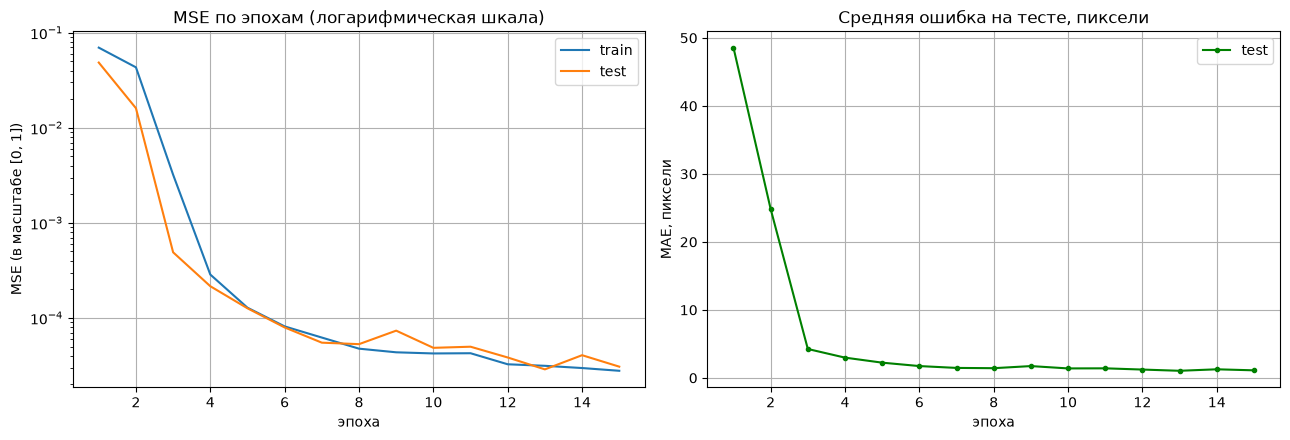

In [11]:
ep_range = range(1, epochs + 1)

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

axes[0].plot(ep_range, train_loss, label="train")
axes[0].plot(ep_range, test_loss, label="test")
axes[0].set_yscale("log")            # ошибка падает на три порядка, иначе ничего не видно
axes[0].set_title("MSE по эпохам (логарифмическая шкала)")
axes[0].set_ylabel("MSE (в масштабе [0, 1])")

axes[1].plot(ep_range, test_mae_px, marker=".", color="green", label="test")
axes[1].set_title("Средняя ошибка на тесте, пиксели")
axes[1].set_ylabel("MAE, пиксели")

for ax in axes:
    ax.set_xlabel("эпоха")
    ax.legend()
    ax.grid(True)

plt.tight_layout()
plt.show()

Кривые train и test идут вплотную друг к другу и обе монотонно вниз — переобучения нет, хотя
картинок для обучения всего 1600. Основное падение приходится на первые три эпохи, дальше кривая
ошибки в пикселях выходит на плато около 1-1.5 пикселя и только слегка колеблется; продолжать
обучение дольше 15 эпох особого смысла нет.

## Часть 3. Метрики и графики

### Шаг 7. Метрики регрессии

Прогноз сети умножаем на 255 и все метрики считаем в пикселях — так их можно читать буквально.
Кроме общих MAE, MSE, RMSE и R^2 отдельно смотрим ошибку по каждой координате.

In [12]:
_, pred, true = predict(test_loader)

pred_px = pred * 255      # возвращаем прогноз в масштаб пикселей
true_px = true * 255

print("MAE  =", round(mean_absolute_error(true_px, pred_px), 2), "пикселя")
print("MSE  =", round(mean_squared_error(true_px, pred_px), 2))
print("RMSE =", round(mean_squared_error(true_px, pred_px) ** 0.5, 2), "пикселя")
print("R2   =", round(r2_score(true_px, pred_px), 4))

MAE  = 1.11 пикселя
MSE  = 2.0
RMSE = 1.41 пикселя
R2   = 0.9994


In [13]:
res = pd.DataFrame(
    [[mean_absolute_error(true_px[:, k], pred_px[:, k]),
      mean_squared_error(true_px[:, k], pred_px[:, k]),
      mean_squared_error(true_px[:, k], pred_px[:, k]) ** 0.5,
      r2_score(true_px[:, k], pred_px[:, k])] for k in [0, 1]],
    index=["координата x", "координата y"],
    columns=["MAE", "MSE", "RMSE", "R2"])
res.round(3)

,MAE,MSE,RMSE,R2
координата x,1.047,1.837,1.355,0.999
координата y,1.172,2.160,1.470,0.999


In [14]:
err = np.abs(pred_px - true_px)

print("средняя ошибка по x:", round(err[:, 0].mean(), 2), "пикселя")
print("средняя ошибка по y:", round(err[:, 1].mean(), 2), "пикселя")
print("худший промах:", round(err.max(), 1), "пикселя")
print("доля картинок, где обе координаты угаданы с точностью до 5 пикселей:",
      round((err.max(axis=1) <= 5).mean(), 3))

средняя ошибка по x: 1.05 пикселя
средняя ошибка по y: 1.17 пикселя
худший промах: 5.8 пикселя
доля картинок, где обе координаты угаданы с точностью до 5 пикселей: 0.992


Сеть предсказывает координаты с точностью около 1 пикселя при размере картинки 256x256,
R^2 = 0.999 по обеим координатам, а худший промах на всей тестовой выборке — меньше 6 пикселей.
Ошибки по x и по y практически одинаковые (1.05 и 1.17 пикселя) — это ожидаемо, задача по осям
симметричная. 99% тестовых картинок угаданы с точностью до 5 пикселей.

### Шаг 8. Прогноз против истины

Рисуем два графика — отдельно для x и для y. Пунктиром показана линия `y = x`: чем ближе точки
к ней, тем точнее прогноз.

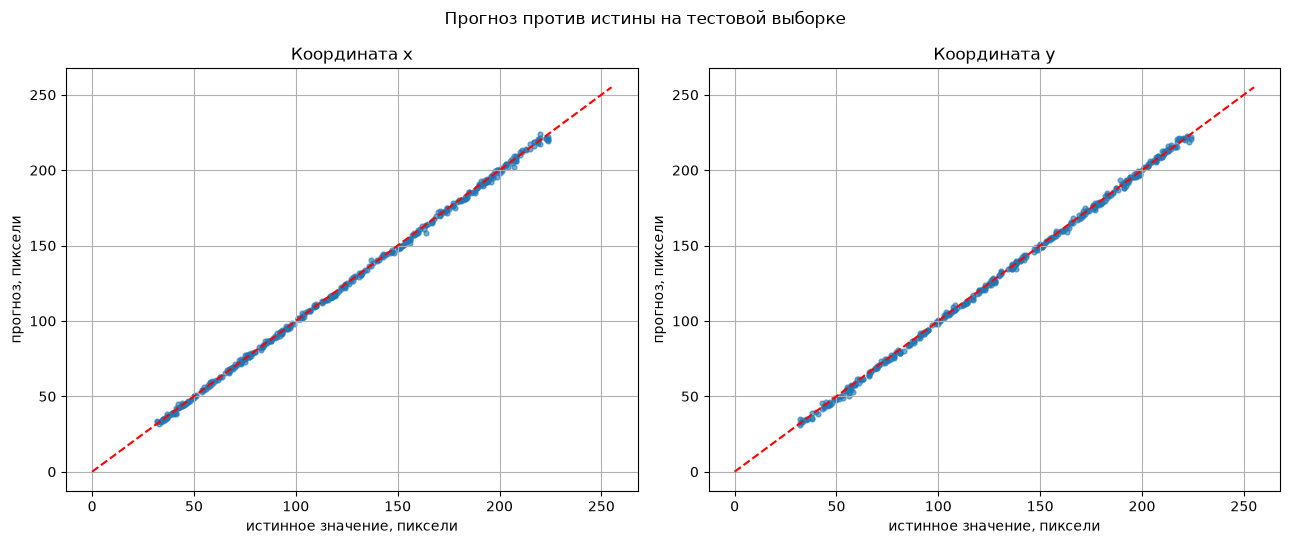

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5.5))

for k, name in [(0, "x"), (1, "y")]:
    ax = axes[k]
    ax.scatter(true_px[:, k], pred_px[:, k], s=12, alpha=0.6)
    ax.plot([0, 255], [0, 255], "r--")          # идеальный прогноз
    ax.set_title("Координата " + name)
    ax.set_xlabel("истинное значение, пиксели")
    ax.set_ylabel("прогноз, пиксели")
    ax.grid(True)

fig.suptitle("Прогноз против истины на тестовой выборке")
plt.tight_layout()
plt.show()

Точки лежат практически на диагонали по всему диапазону 32-224, заметных отклонений нет ни у
краёв, ни в середине — сеть не «стягивает» прогноз к центру картинки, как это было бы при
недообучении.

Красный крест и чёрный крестик сливаются в один — на масштабе картинки промах в 1-2 пикселя
просто не виден. Сеть попадает в центр солнца и на однотонном небе, и когда рядом облака.

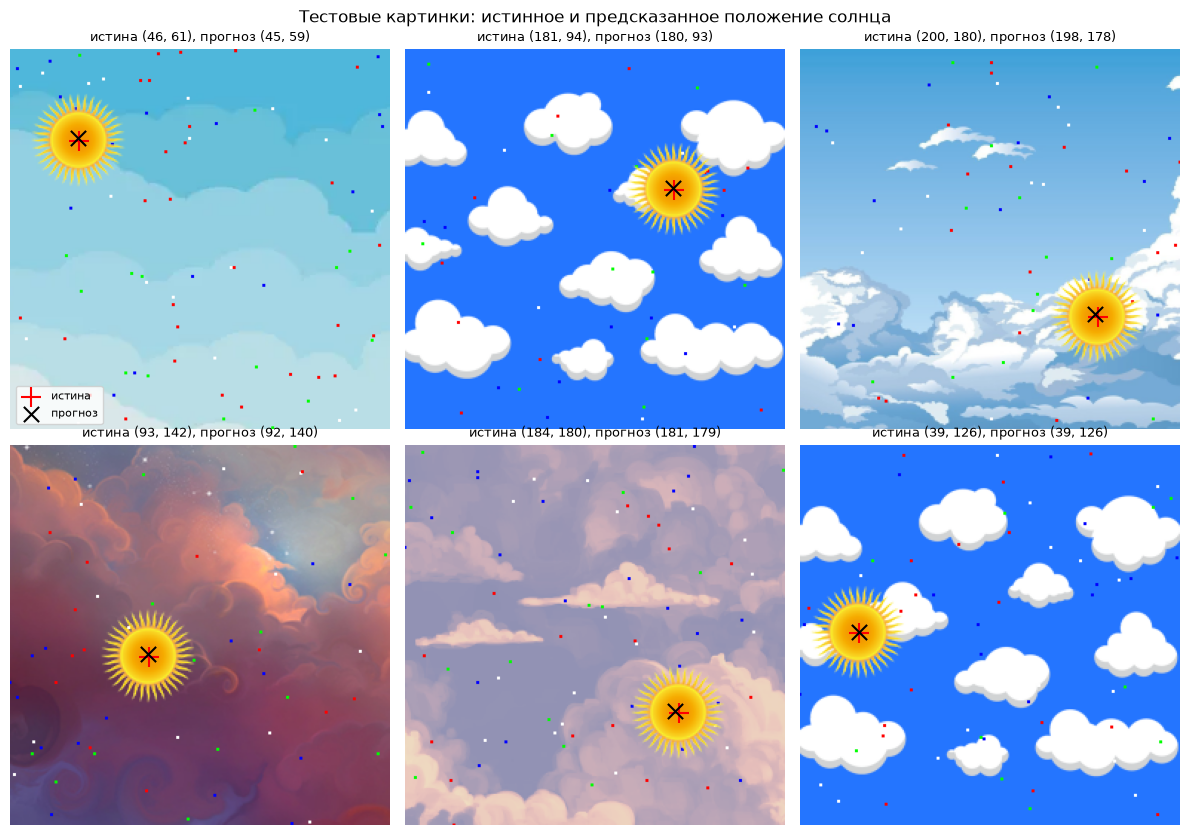

In [16]:
fig, axes = plt.subplots(2, 3, figsize=(12, 8.5))
test_names = test_df.reset_index(drop=True)["image"]

for ax, i in zip(axes.flatten(), range(6)):
    img = Image.open(os.path.join("images", test_names[i])).convert("RGB")
    ax.imshow(img)
    ax.scatter(true_px[i, 0], true_px[i, 1], s=200, marker="+", c="red", label="истина")
    ax.scatter(pred_px[i, 0], pred_px[i, 1], s=120, marker="x", c="black", label="прогноз")
    ax.set_title(f"истина ({true_px[i, 0]:.0f}, {true_px[i, 1]:.0f}), "
                 f"прогноз ({pred_px[i, 0]:.0f}, {pred_px[i, 1]:.0f})", fontsize=9)
    ax.axis("off")

axes[0, 0].legend(loc="lower left", fontsize=8)
fig.suptitle("Тестовые картинки: истинное и предсказанное положение солнца")
plt.tight_layout()
plt.show()

Красный крест и чёрный крестик визуально сливаются — на масштабе картинки промах в 1-3 пикселя
просто не виден. Сеть попадает в центр солнца даже когда рядом облака.

## Выводы

- Задача регрессии по картинке решается той же свёрточной архитектурой, что и классификация в
  задании 13; менять пришлось только три вещи: 3 входных канала вместо 1, 2 линейных выхода без
  softmax вместо 10 и `nn.MSELoss` вместо `nn.CrossEntropyLoss`. Метрики тоже регрессионные —
  MAE, MSE, RMSE, R^2, как в задании 09.
- Данные готовились «способом для регрессии»: свой класс на `torch.utils.data.Dataset` читает
  картинку с диска по имени файла из `labels.csv` и возвращает пару (картинка, тензор из двух
  координат), а `DataLoader` собирает из этого батчи по 32. Метка здесь берётся не из имени папки,
  как было бы в классификации, а из csv-таблицы.
- Результат: MAE = 1.11 пикселя и RMSE = 1.41 пикселя при размере картинки 256x256, R^2 = 0.9994,
  99% тестовых картинок угаданы с точностью до 5 пикселей. Это ожидаемо: геометрически задача
  простая — солнце это яркое компактное пятно, свёрточным фильтрам достаточно его найти и передать
  положение в полносвязную часть. Небольшая сеть на 137 тысяч параметров и 15 эпох справляются,
  переобучения на 1600 картинках не видно, хотя картинки лежат на разном фоне (однотонное небо,
  облака, закат) и рядом бывают облака и цветные точки-помехи.
- Две детали заметно влияли на результат. Во-первых, картинки в датасете четырёхканальные (RGBA),
  поэтому при чтении обязателен `.convert("RGB")` — иначе на вход сети приедет 4 канала вместо 3.
  Во-вторых, целевые координаты стоит отмасштабировать в [0, 1], а метрики считать уже в пикселях:
  на «сырых» числах до 255 квадратичная ошибка на старте огромная и обучение идёт хуже.
- Уменьшение картинок до 64x64 — компромисс из-за счёта на процессоре: на полном разрешении
  256x256 одна эпоха занимала бы минуты, а на 64x64 весь ноутбук считается около трёх минут.
  Точность от этого почти не пострадала: остаточный промах в 1 пиксель полной картинки — это
  четверть пикселя уменьшенной, то есть разрешение здесь уже не является узким местом.